# Stage 3 — Track A v3: Prawn / Tuna / Other

**What v3 fixes**
1. **Crop-size confound.** Stage 1's boxes are stretched to 512x512 before Stage 2 sees them: about 3x for tuna, about 1x
   for prawn. Stretching blurs, which lowers edge strength and brightness spread for reasons unrelated to the disturbance.
   Texture is now also measured at the *original photo's* pixel grid (`in_L_std_native`, `in_edge_native`). This undoes
   both the box stretch and Stage 1's resize of the whole photo to 512x512 (tuna files are 256x256).
2. **"Other" crops now have box sizes.** Each saved crop is traced back to its source photo by filename and re-run through the
   same pipeline as prawn/tuna, so all three classes go through identical code. The boxes are saved to
   `stage3_other_class/_boxes.json`. A check confirms each re-created crop matches the saved PNG.
3. **Lost rows are explained.** Cell 7 says whether each dropped image was not flagged by Stage 1, left empty by Stage 2
   (with Stage 2's highest confidence, to compare against the 0.35 threshold), or under the 80-pixel floor.

**Scale diagnostics.** `scale_only` (stretch factors alone) and `signature_asis` (texture on the stretched crop) are
reported but can never be selected. If `scale_only` scores close to the chosen set, the class separation is not trustworthy.

**Evaluation discipline (unchanged).** The feature set is chosen by cross-validation on TRAINING rows only.
The held-out eval set is scored once, at the end; its ablation table is for reporting only.

**Still not removable with this data:** all prawn photos are bright teal water and all tuna/other photos are dark navy, and
the photos come from different cameras. Scene colour and camera resolution can be measured (cell 9) but not tested away.

In [1]:
# --- Cell 1: Imports and config ---
import json
import pickle
import random
from pathlib import Path

import cv2
import numpy as np
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from transformers import SegformerForSemanticSegmentation
from skimage.segmentation import slic
from skimage.feature import graycomatrix, graycoprops, local_binary_pattern
from scipy import ndimage
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

# --- Paths: update to match your machine ---
PRAWN_IMG_DIR = Path(r"C:\Users\bcura\AI PostGrad Project\Saqqara-Marine-Anomaly-Detection\Stage_02\prawn_annotation_training\images\default")
TUNA_IMG_DIR  = Path(r"C:\Users\bcura\AI PostGrad Project\Saqqara-Marine-Anomaly-Detection\Stage_02\tuna_annotation_training\images\default")

PRAWN_T1_JSON = Path("prawn_instances_default_t1.json")
PRAWN_T2_JSON = Path("prawn_instances_default_t2.json")
TUNA_T1_JSON  = Path("tuna_instances_default_t1.json")
TUNA_T2_JSON  = Path("tuna_instances_default_t2.json")

STAGE1_CONFIG_PATH = Path("stage1_final_config.json")
STAGE1_BUCKET_REF_PATH = Path("stage1_bucket_ref.pkl")
SEGFORMER_CHECKPOINT_PATH = Path("stage2_output/segformer_b0_epoch30.pt")   # best checkpoint per stage2_scored_summary.json

OTHER_CLASS_DIR = Path("stage3_other_class")   # already populated with saved crops from Stage 2's notebook
# Where the "other" crops originally came from (needed to recover each crop's box and source size)
NEGATIVE_DIR = Path(r"C:\Users\bcura\AI PostGrad Project\Saqqara-Marine-Anomaly-Detection\Stage_01\data\normal_sea\heldout_split")
BASELINE_DIR = Path(r"C:\Users\bcura\AI PostGrad Project\Saqqara-Marine-Anomaly-Detection\Stage_01\data\normal_sea\baseline_split")

with open(STAGE1_CONFIG_PATH) as f:
    stage1_config = json.load(f)
with open(STAGE1_BUCKET_REF_PATH, "rb") as f:
    stage1_bucket_ref = pickle.load(f)

IMG_SIZE = tuple(stage1_config["img_size"])
IMAGENET_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
IMAGENET_STD = np.array([0.229, 0.224, 0.225], dtype=np.float32)

STAGE2_PROB_THRESHOLD = 0.35
STAGE2_MIN_MASK_PIXELS = 80
STAGE1_DILATION_ITERS = 2
CROP_PADDING_PX = 20
N_OTHER_EVAL = 15

# --- Second data batch: confirmed tuna sightings + new sea images ---
NEW_TUNA_DIR = Path(r"C:\Users\bcura\AI PostGrad Project\Saqqara-Marine-Anomaly-Detection\Stage_03\Val_data\TUNA")   # ~500 confirmed tuna images
NEW_SEA_DIR = Path(r"C:\Users\bcura\AI PostGrad Project\Saqqara-Marine-Anomaly-Detection\Stage_03\Val_data\SEA")        # ~900 new sea images
NEW_TUNA_SAMPLE_SIZE = 200
NEW_SEA_SAMPLE_SIZE = 200
N_NEW_TUNA_EVAL = 40   # held out fresh, never used before - becomes the ONLY tuna eval going forward
RING_PX = 25                  # width of the 'surroundings' ring used for contrast/colour features
ROBUSTNESS_TOLERANCE = 0.05   # prefer signature_native if its CV macro-F1 is within this of the best candidate
MIN_NATIVE_PX = 24            # never shrink a crop below this many pixels per side when measuring native texture
MIN_NATIVE_MASK_PX = 30       # a mask smaller than this at native scale is too small to measure texture on
REPRO_TOL = 0.02              # max mean pixel difference when re-creating a saved 'other' crop

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Stage 1 config loaded. IMG_SIZE={IMG_SIZE}")
print(f"Using device: {device}")

random.seed(42)
np.random.seed(42)

Stage 1 config loaded. IMG_SIZE=(512, 512)
Using device: cpu


In [2]:
# --- Cell 2: Load SegFormer-B0 with the best checkpoint ---

model = SegformerForSemanticSegmentation.from_pretrained(
    "nvidia/segformer-b0-finetuned-ade-512-512", num_labels=2,
    id2label={0: "background", 1: "anomaly"}, label2id={"background": 0, "anomaly": 1},
    ignore_mismatched_sizes=True,
)
model.load_state_dict(torch.load(SEGFORMER_CHECKPOINT_PATH, map_location=device))
model.to(device)
model.eval()
print(f"Loaded checkpoint: {SEGFORMER_CHECKPOINT_PATH}")

[transformers] You passed `num_labels=2` which is incompatible to the `id2label` map of length `150`.


Loading weights:   0%|          | 0/208 [00:00<?, ?it/s]

[transformers] SegformerForSemanticSegmentation LOAD REPORT from: nvidia/segformer-b0-finetuned-ade-512-512
Key                           | Status   |                                                                                                     
------------------------------+----------+-----------------------------------------------------------------------------------------------------
decode_head.classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([150, 256, 1, 1]) vs model:torch.Size([2, 256, 1, 1])
decode_head.classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([150]) vs model:torch.Size([2])                      

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


Loaded checkpoint: stage2_output\segformer_b0_epoch30.pt


In [3]:
# --- Cell 3: Ported Stage 1 detector (texture rule OR local-brightness rule) ---

S1_N_SEGMENTS = stage1_config["n_segments"]
S1_COMPACTNESS = stage1_config["compactness"]
S1_GLCM_LEVELS = stage1_config["glcm_levels"]
S1_Z_THRESH = stage1_config["z_thresh"]
S1_GLINT_THRESH = stage1_config["glint_thresh"]
S1_MIN_COMPONENT_AREA_PX = stage1_config["min_component_area_px"]
S1_MIN_FEATURES_FLAGGED = stage1_config["min_features_flagged"]
S1_BUCKET_EDGES = np.array(stage1_config["bucket_edges"])
S1_LOCAL_Z_THRESH = stage1_config.get("local_z_thresh", 999)
S1_MIN_AREA_LOCAL = stage1_config.get("min_area_local", 999999999)
FEATURE_KEYS = ["contrast_L", "homogeneity_L", "energy_L", "contrast_a", "lbp_var"]

def suppress_glint(img_bgr, thresh=S1_GLINT_THRESH, dilate_iter=2):
    lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
    L = lab[:, :, 0]
    glint_mask = (L > thresh).astype(np.uint8)
    kernel = np.ones((5, 5), np.uint8)
    glint_mask = cv2.dilate(glint_mask, kernel, iterations=dilate_iter)
    return cv2.morphologyEx(glint_mask, cv2.MORPH_CLOSE, kernel)

def preprocess_image_s1(path, glint_thresh=S1_GLINT_THRESH):
    img_bgr = cv2.resize(cv2.imread(str(path)), IMG_SIZE)
    lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
    glint_mask = suppress_glint(img_bgr, glint_thresh)
    rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    return lab, glint_mask, rgb

def quantize_s1(patch, levels=S1_GLCM_LEVELS):
    return (patch.astype(np.float32) / 256 * levels).astype(np.uint8)

def glcm_props_s1(patch_q, levels=S1_GLCM_LEVELS):
    glcm = graycomatrix(patch_q, distances=[1], angles=[0], levels=levels, symmetric=True, normed=True)
    return (float(graycoprops(glcm, 'contrast')[0, 0]), float(graycoprops(glcm, 'homogeneity')[0, 0]), float(graycoprops(glcm, 'energy')[0, 0]))

def extract_superpixel_features_s1(img_lab, glint_mask, n_segments=S1_N_SEGMENTS, compactness=S1_COMPACTNESS):
    L_channel, a_channel = img_lab[:, :, 0], img_lab[:, :, 1]
    segments = slic(img_lab, n_segments=n_segments, compactness=compactness, start_label=1)
    objects = ndimage.find_objects(segments)
    features = []
    for seg_id, bbox in enumerate(objects, start=1):
        if bbox is None:
            continue
        y_slice, x_slice = bbox
        local_mask = segments[y_slice, x_slice] == seg_id
        if glint_mask[y_slice, x_slice][local_mask].mean() > 0.5:
            continue
        patch_L, patch_a = L_channel[y_slice, x_slice], a_channel[y_slice, x_slice]
        if patch_L.shape[0] < 2 or patch_L.shape[1] < 2:
            continue
        contrast_L, homogeneity_L, energy_L = glcm_props_s1(quantize_s1(patch_L))
        contrast_a, _, _ = glcm_props_s1(quantize_s1(patch_a))
        lbp_var = float(np.var(local_binary_pattern(patch_L, P=8, R=1, method='uniform')))
        features.append({"seg_id": int(seg_id), "contrast_L": contrast_L, "homogeneity_L": homogeneity_L,
                          "energy_L": energy_L, "contrast_a": contrast_a, "lbp_var": lbp_var, "mean_L": float(patch_L.mean())})
    return segments, features

def image_sea_state_score(img_lab, glint_mask):
    L = img_lab[:, :, 0]
    valid = glint_mask == 0
    return float(np.mean(L[valid] if valid.any() else L))

def assign_bucket_from_score(score, edges=S1_BUCKET_EDGES):
    return int(np.searchsorted(edges, score))

def score_region_deviation_s1(feat, baseline_ref, z_thresh, min_features_flagged):
    z_scores = {k: abs(feat[k] - baseline_ref[k][0]) / (baseline_ref[k][1] + 1e-6) for k in FEATURE_KEYS}
    return sum(1 for z in z_scores.values() if z > z_thresh) >= min_features_flagged

def _region_with_bbox(flagged_mask, min_area, dilation_iters=STAGE1_DILATION_ITERS):
    if dilation_iters > 0:
        flagged_mask = ndimage.binary_dilation(flagged_mask, iterations=dilation_iters)
    labeled, n_components = ndimage.label(flagged_mask)
    if n_components == 0:
        return False, 0, None
    sizes = ndimage.sum(flagged_mask, labeled, range(1, n_components + 1))
    biggest_label = int(np.argmax(sizes)) + 1
    max_component = float(sizes[biggest_label - 1])
    is_detected = max_component >= min_area
    bbox = None
    if is_detected:
        y_slice, x_slice = ndimage.find_objects(labeled)[biggest_label - 1]
        bbox = (x_slice.start, y_slice.start, x_slice.stop, y_slice.stop)
    return is_detected, max_component, bbox

def texture_rule_with_bbox(segments, feats, baseline_ref, z_thresh=S1_Z_THRESH, min_area=S1_MIN_COMPONENT_AREA_PX, min_features_flagged=S1_MIN_FEATURES_FLAGGED):
    flagged_ids = {f["seg_id"] for f in feats if score_region_deviation_s1(f, baseline_ref, z_thresh, min_features_flagged)}
    if not flagged_ids:
        return False, 0, None
    return _region_with_bbox(np.isin(segments, list(flagged_ids)), min_area)

def local_brightness_rule_with_bbox(feats, segments, local_z_thresh=S1_LOCAL_Z_THRESH, min_area_local=S1_MIN_AREA_LOCAL):
    if not feats:
        return False, 0, None
    mean_Ls = np.array([f["mean_L"] for f in feats])
    img_mean, img_std = mean_Ls.mean(), mean_Ls.std()
    flagged_ids = {f["seg_id"] for f in feats if abs(f["mean_L"] - img_mean) / (img_std + 1e-6) > local_z_thresh}
    if not flagged_ids:
        return False, 0, None
    return _region_with_bbox(np.isin(segments, list(flagged_ids)), min_area_local)

def get_flagging_result_with_bbox(segments, feats, baseline_ref):
    tex_detected, tex_area, tex_bbox = texture_rule_with_bbox(segments, feats, baseline_ref)
    local_detected, local_area, local_bbox = local_brightness_rule_with_bbox(feats, segments)
    if not tex_detected and not local_detected:
        return False, 0, None
    if tex_detected and local_detected:
        return (True, tex_area, tex_bbox) if tex_area >= local_area else (True, local_area, local_bbox)
    return (True, tex_area, tex_bbox) if tex_detected else (True, local_area, local_bbox)

print("Stage 1 detector ported and ready.")

Stage 1 detector ported and ready.


In [4]:
# --- Cell 4: Connected pipeline (Stage 1 -> crop -> Stage 2) ---

def run_connected_pipeline(path, bucket_ref=stage1_bucket_ref):
    lab, glint_mask, rgb = preprocess_image_s1(path)
    segments, feats = extract_superpixel_features_s1(lab, glint_mask)
    bucket = assign_bucket_from_score(image_sea_state_score(lab, glint_mask))
    is_detected, max_component, bbox = get_flagging_result_with_bbox(segments, feats, bucket_ref[bucket])

    result = {"path": str(path), "rgb": rgb, "is_detected": is_detected,
              "bbox": None, "crop": None, "stage2_mask": None, "n_flagged_px_stage2": 0,
              "stage2_raw_px": 0, "stage2_max_prob": None}

    if is_detected and bbox is not None:
        x0, y0, x1, y1 = bbox
        H, W = rgb.shape[:2]
        x0p, y0p = max(0, x0 - CROP_PADDING_PX), max(0, y0 - CROP_PADDING_PX)
        x1p, y1p = min(W, x1 + CROP_PADDING_PX), min(H, y1 + CROP_PADDING_PX)
        crop = rgb[y0p:y1p, x0p:x1p]
        result["bbox"] = (x0p, y0p, x1p, y1p)

        if crop.size > 0:
            crop_img = Image.fromarray(crop).resize(IMG_SIZE, Image.BILINEAR)
            crop_arr = np.array(crop_img, dtype=np.float32) / 255.0
            crop_norm = (crop_arr - IMAGENET_MEAN) / IMAGENET_STD
            pixel_values = torch.from_numpy(crop_norm.transpose(2, 0, 1)).unsqueeze(0).to(device)
            with torch.no_grad():
                outputs = model(pixel_values=pixel_values)
                logits = F.interpolate(outputs.logits, size=IMG_SIZE, mode="bilinear", align_corners=False)
                probs = F.softmax(logits, dim=1)[0, 1].cpu().numpy()
            pred = (probs > STAGE2_PROB_THRESHOLD).astype(np.uint8)
            result["stage2_raw_px"] = int(pred.sum())            # pixels above threshold, before the noise floor
            result["stage2_max_prob"] = float(probs.max())       # highest anomaly probability anywhere in the crop
            if pred.sum() < STAGE2_MIN_MASK_PIXELS:
                pred = np.zeros_like(pred)
            result["crop"] = crop_arr
            result["stage2_mask"] = pred
            result["n_flagged_px_stage2"] = int(pred.sum())

    return result

print("Connected pipeline ready.")

Connected pipeline ready.


In [5]:
# --- Cell 5: Load prawn/tuna annotations, rebuild train/eval record lists ---

def load_coco(path):
    with open(path) as f:
        return json.load(f)

def coco_to_records(coco, img_dir, dataset_name):
    img_by_id = {img["id"]: img for img in coco["images"]}
    segs_by_image = {img["id"]: [] for img in coco["images"]}
    for ann in coco["annotations"]:
        segs_by_image[ann["image_id"]].extend(ann["segmentation"])
    records = []
    for img_id, img in img_by_id.items():
        records.append({"path": img_dir / img["file_name"], "filename": img["file_name"],
                         "width": img["width"], "height": img["height"],
                         "segmentations": segs_by_image[img_id], "dataset": dataset_name})
    return records

prawn_t1 = coco_to_records(load_coco(PRAWN_T1_JSON), PRAWN_IMG_DIR, "prawn")
prawn_t2 = coco_to_records(load_coco(PRAWN_T2_JSON), PRAWN_IMG_DIR, "prawn")
tuna_t1 = coco_to_records(load_coco(TUNA_T1_JSON), TUNA_IMG_DIR, "tuna")
tuna_t2 = coco_to_records(load_coco(TUNA_T2_JSON), TUNA_IMG_DIR, "tuna")

prawn_t2_filenames = {r["filename"] for r in prawn_t2}
tuna_t2_filenames = {r["filename"] for r in tuna_t2}
prawn_train_records = [r for r in prawn_t1 if r["filename"] not in prawn_t2_filenames]
tuna_train_records = [r for r in tuna_t1 if r["filename"] not in tuna_t2_filenames]
prawn_eval_records = [r for r in prawn_t1 if r["filename"] in prawn_t2_filenames]
tuna_eval_records = [r for r in tuna_t1 if r["filename"] in tuna_t2_filenames]

print(f"Prawn: {len(prawn_train_records)} train, {len(prawn_eval_records)} eval")
print(f"Tuna:  {len(tuna_train_records)} train, {len(tuna_eval_records)} eval")

Prawn: 15 train, 10 eval
Tuna:  16 train, 10 eval


In [6]:
# --- Cell 6: Track A features: shape, signature (as-is and native-scale), scene, scale diagnostics ---

LABELS = ["prawn", "tuna", "other"]

def _sobel_mag(gray):
    return np.sqrt(cv2.Sobel(gray, cv2.CV_32F, 1, 0) ** 2 + cv2.Sobel(gray, cv2.CV_32F, 0, 1) ** 2)

def texture_at_native_scale(crop_u8, mask, bbox, src_size):
    """Texture measured on the crop shrunk back to the ORIGINAL file's pixel grid, so it is not
    inflated or deflated by our own resizing. The box covers (box_w x src_w / 512) file pixels across;
    the 512x512 crop is shrunk to that size (never enlarged, never below MIN_NATIVE_PX)."""
    x0, y0, x1, y1 = bbox
    src_w, src_h = src_size
    fw, fh = IMG_SIZE
    nw = int(np.clip(round((x1 - x0) * src_w / fw), MIN_NATIVE_PX, fw))
    nh = int(np.clip(round((y1 - y0) * src_h / fh), MIN_NATIVE_PX, fh))
    small = cv2.resize(crop_u8, (nw, nh), interpolation=cv2.INTER_AREA)
    m_small = cv2.resize(mask.astype(np.float32), (nw, nh), interpolation=cv2.INTER_AREA) > 0.5
    if m_small.sum() < MIN_NATIVE_MASK_PX:
        return None
    gray = cv2.cvtColor(small, cv2.COLOR_RGB2GRAY).astype(np.float32)
    L = cv2.cvtColor(small, cv2.COLOR_RGB2LAB)[:, :, 0].astype(np.float32)
    return float(L[m_small].std()), float(_sobel_mag(gray)[m_small].mean()), nw

def extract_track_a_features(result):
    """Returns (features, None) on success, or (None, reason) if the row is unusable.
    Needs 'stage2_mask' (512x512 0/1), 'crop' (512x512x3 float 0-1 RGB), 'bbox' and 'path'."""
    mask, crop, bbox = result.get("stage2_mask"), result.get("crop"), result.get("bbox")
    if mask is None or crop is None or bbox is None:
        return None, "missing crop/mask/box"
    mask_area = int(mask.sum())
    if mask_area == 0:
        return None, "empty mask"
    inside = mask.astype(bool)

    # ---- shape (baseline only) ----
    ys, xs = np.where(inside)
    mask_h = ys.max() - ys.min() + 1
    mask_w = xs.max() - xs.min() + 1
    elongation = max(mask_w, mask_h) / max(1, min(mask_w, mask_h))
    extent = mask_area / (mask_w * mask_h)
    fill_ratio = mask_area / mask.size                       # fraction of the crop covered by the mask

    # ---- pixel content on the stretched 512x512 crop ----
    crop_u8 = (np.clip(crop, 0, 1) * 255).astype(np.uint8)   # RGB
    lab = cv2.cvtColor(crop_u8, cv2.COLOR_RGB2LAB).astype(np.float32)
    gray = cv2.cvtColor(crop_u8, cv2.COLOR_RGB2GRAY).astype(np.float32)
    grad = _sobel_mag(gray)
    L, a, b = lab[:, :, 0], lab[:, :, 1], lab[:, :, 2]

    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (2 * RING_PX + 1, 2 * RING_PX + 1))
    ring = cv2.dilate(mask.astype(np.uint8), kernel).astype(bool) & ~inside
    if ring.sum() < 50:
        ring = ~inside
    if ring.sum() < 50:
        return None, "mask covers almost the whole crop"

    # ---- native-scale texture + scale diagnostics ----
    with Image.open(result["path"]) as im:
        src_size = im.size                                    # (width, height) of the original file
    native = texture_at_native_scale(crop_u8, mask, bbox, src_size)
    if native is None:
        return None, "mask too small at native scale"
    in_L_std_native, in_edge_native, native_w = native

    box_w = max(1, bbox[2] - bbox[0])
    return {
        # shape
        "fill_ratio": fill_ratio, "elongation": elongation, "extent": extent,
        # signature, measured on the stretched crop (kept as a diagnostic)
        "in_L_std": float(L[inside].std()), "in_edge": float(grad[inside].mean()),
        # signature, measured at native scale
        "in_L_std_native": in_L_std_native, "in_edge_native": in_edge_native,
        "contrast_ring": float(L[inside].mean() - L[ring].mean()),
        # scene
        "in_L": float(L[inside].mean()), "ring_L": float(L[ring].mean()),
        "in_a": float(a[inside].mean()), "ring_a": float(a[ring].mean()),
        "in_b": float(b[inside].mean()), "ring_b": float(b[ring].mean()),
        # scale diagnostics
        "crop_scale": IMG_SIZE[0] / box_w,                                   # stretch of Stage 1's box to 512
        "total_upscale": IMG_SIZE[0] * IMG_SIZE[0] / (box_w * src_size[0]),  # stretch relative to the real photo
        "src_w": float(src_size[0]), "native_w": float(native_w),
    }, None

print("Feature function ready.")

Feature function ready.


In [7]:
# --- Cell 7: Run prawn/tuna through the connected pipeline; say WHY any image is lost ---

def features_or_reason(result):
    if not result["is_detected"]:
        return None, "stage1_not_flagged"
    if result["crop"] is None:
        return None, "empty_crop"
    if result["n_flagged_px_stage2"] == 0:
        if result["stage2_raw_px"] == 0:
            return None, f"stage2_empty (max prob {result['stage2_max_prob']:.2f}, threshold {STAGE2_PROB_THRESHOLD})"
        return None, f"stage2_under_pixel_floor ({result['stage2_raw_px']} px < {STAGE2_MIN_MASK_PIXELS})"
    feats, why = extract_track_a_features(result)
    if feats is None:
        return None, f"features_unusable: {why}"
    return feats, None

all_skips = []   # (class, split, filename, reason)

def build_track_a_rows(records, label, split):
    rows = []
    for r in records:
        result = run_connected_pipeline(r["path"])
        feats, reason = features_or_reason(result)
        if feats is None:
            all_skips.append((label, split, r["filename"], reason))
            continue
        feats.update(label=label, filename=r["filename"])
        rows.append(feats)
    print(f"{label} {split}: {len(rows)} usable / {len(records)} total")
    return rows

prawn_train_rows = build_track_a_rows(prawn_train_records, "prawn", "train")
prawn_eval_rows = build_track_a_rows(prawn_eval_records, "prawn", "eval")
tuna_train_rows = build_track_a_rows(tuna_train_records, "tuna", "train")
tuna_eval_rows = build_track_a_rows(tuna_eval_records, "tuna", "eval")

print("\nImages lost before Track A:")
if not all_skips:
    print("  none")
for label, split, name, reason in all_skips:
    print(f"  {label:<5} {split:<5} {name[:34]:<34} {reason}")

from collections import Counter
cause = lambda s: s.split(" (")[0].split(":")[0]
print("\nBy cause:", dict(Counter(cause(s[3]) for s in all_skips)) or "none")

prawn train: 15 usable / 15 total
prawn eval: 10 usable / 10 total
tuna train: 13 usable / 16 total
tuna eval: 7 usable / 10 total

Images lost before Track A:
  tuna  train flipped_22_png.rf.8d809f5e6800c6f6 features_unusable: mask too small at native scale
  tuna  train flipped_31_png.rf.842075409849fc72 stage2_empty (max prob 0.01, threshold 0.35)
  tuna  train flipped_55_png.rf.c8751fb599b8f441 features_unusable: mask too small at native scale
  tuna  eval  flipped_12_png.rf.e8f1a65733e71900 stage2_empty (max prob 0.00, threshold 0.35)
  tuna  eval  flipped_13_png.rf.2f8ab9180153a8f5 stage2_empty (max prob 0.01, threshold 0.35)
  tuna  eval  flipped_15_png.rf.6c23fd8f1ddabcaf stage2_empty (max prob 0.00, threshold 0.35)

By cause: {'features_unusable': 2, 'stage2_empty': 4}


In [8]:
# --- Cell 8: Re-create the 'other' crops by tracing each saved PNG back to its source photo ---
# Each saved file is named other_<n>_<source name>.png. The source photo is found in NEGATIVE_DIR or
# BASELINE_DIR and run through the SAME connected pipeline as prawn/tuna, which recovers the box.
# The re-created crop is compared with the saved PNG to prove it is the same crop.

import re

NAME_RE = re.compile(r"^other_\d+_(.+)\.png$")

source_index = {}
for d in [NEGATIVE_DIR, BASELINE_DIR]:
    for p in list(d.glob("*.jpg")) + list(d.glob("*.png")):
        source_index.setdefault(p.stem, []).append(p)
print(f"Indexed {sum(len(v) for v in source_index.values())} source photos from NEGATIVE_DIR + BASELINE_DIR")

saved_pngs = sorted(OTHER_CLASS_DIR.glob("other_*.png"))
print(f"Found {len(saved_pngs)} saved 'other' crops in {OTHER_CLASS_DIR}")

other_rows, other_skips, boxes_meta, repro_warnings = [], [], {}, []
for png in saved_pngs:
    m = NAME_RE.match(png.name)
    candidates = source_index.get(m.group(1), []) if m else []
    if not candidates:
        other_skips.append((png.name, "source photo not found in NEGATIVE_DIR / BASELINE_DIR"))
        continue

    saved = np.array(Image.open(png).convert("RGB").resize(IMG_SIZE, Image.BILINEAR), dtype=np.float32) / 255.0
    best = None
    for cand in candidates:                                   # normally exactly one
        res = run_connected_pipeline(cand)
        diff = float(np.abs(res["crop"] - saved).mean()) if res["crop"] is not None else float("inf")
        if best is None or diff < best[1]:
            best = (res, diff)
    result, diff = best

    feats, reason = features_or_reason(result)
    if feats is None:
        other_skips.append((png.name, reason))
        continue
    if diff > REPRO_TOL:
        repro_warnings.append((png.name, diff))
    feats.update(label="other", filename=png.name)
    other_rows.append(feats)
    boxes_meta[png.name] = {"source_path": result["path"], "box_in_512_frame": [int(v) for v in result["bbox"]],
                            "crop_scale": feats["crop_scale"], "src_w": feats["src_w"]}

print(f"other: {len(other_rows)} usable / {len(saved_pngs)} saved")
for name, reason in other_skips:
    print(f"  skipped {name[:44]:<44} {reason}")
if repro_warnings:
    print(f"\nWARNING: {len(repro_warnings)} re-created crops differ from the saved PNG by more than {REPRO_TOL}. "
          f"The Stage 1 config or SegFormer checkpoint may not match the ones used when these were gathered:")
    for name, d in repro_warnings[:10]:
        print(f"  {name[:44]:<44} diff={d:.3f}")
else:
    print(f"Reproduction check passed: every re-created crop matches its saved PNG (tolerance {REPRO_TOL}).")

with open(OTHER_CLASS_DIR / "_boxes.json", "w") as f:
    json.dump(boxes_meta, f, indent=2)
print(f"Saved box sizes to {OTHER_CLASS_DIR / '_boxes.json'}")

random.shuffle(other_rows)
other_eval_rows = other_rows[:N_OTHER_EVAL]
other_train_rows = other_rows[N_OTHER_EVAL:]
print(f"other: {len(other_train_rows)} train, {len(other_eval_rows)} held-out eval")

Indexed 4636 source photos from NEGATIVE_DIR + BASELINE_DIR
Found 65 saved 'other' crops in stage3_other_class
other: 65 usable / 65 saved
Reproduction check passed: every re-created crop matches its saved PNG (tolerance 0.02).
Saved box sizes to stage3_other_class\_boxes.json
other: 50 train, 15 held-out eval


## Folding in the second data batch: confirmed tuna sightings + new sea images

**What happens to the OLD tuna eval set (7 rows, cell 7 above).** It has been looked at across three
rounds of development (v1, v2, v3) and can no longer serve as an honest test - so it is folded into
TRAINING here, not discarded. The held-out slice of the NEW confirmed sightings becomes the only tuna
eval used from this point on.

**Prawn's old eval set is left untouched.** There is no replacement for it yet, so it keeps serving as
eval, with the same caveat as before: it has also been looked at more than once.

**A new imbalance, on purpose, worth watching.** Tuna's training count is about to jump from 13 to
roughly 150+, while prawn stays at 15. `class_weight="balanced"` in the classifier helps but does not
fully erase a shift this size. Check tuna's precision specifically after retraining, not just recall -
a model that leans heavily toward predicting tuna would show that as prawn/other being pulled toward
tuna, not as tuna's own numbers looking worse.

In [9]:
# --- New confirmed tuna sightings: same pipeline, same skip-reason reporting as cell 7 ---

def sample_records(folder, n, label):
    paths = list(Path(folder).glob("*.jpg")) or list(Path(folder).glob("*.png"))
    print(f"Found {len(paths)} images in {folder}")
    if n < len(paths):
        paths = random.sample(paths, n)
    return [{"path": p, "filename": p.name} for p in paths]

new_tuna_records = sample_records(NEW_TUNA_DIR, NEW_TUNA_SAMPLE_SIZE, "tuna")
new_tuna_rows = build_track_a_rows(new_tuna_records, "tuna", "new_batch")

random.shuffle(new_tuna_rows)
n_eval = min(N_NEW_TUNA_EVAL, len(new_tuna_rows) - 1)   # keep at least 1 row for training
new_tuna_eval_rows = new_tuna_rows[:n_eval]
new_tuna_train_rows = new_tuna_rows[n_eval:]
print(f"\nNew tuna: {len(new_tuna_train_rows)} train, {len(new_tuna_eval_rows)} held-out eval (never used before)")

Found 539 images in C:\Users\bcura\AI PostGrad Project\Saqqara-Marine-Anomaly-Detection\Stage_03\Val_data\TUNA
tuna new_batch: 139 usable / 200 total

New tuna: 99 train, 40 held-out eval (never used before)


In [10]:
# --- New sea images: harvest additional 'other' candidates the same way as before ---
# Only images Stage 1 flags AND Stage 2 also masks are usable - everything else is correctly
# discarded before it ever reaches Track A, same logic as the original 'other' gathering.

new_sea_records = sample_records(NEW_SEA_DIR, NEW_SEA_SAMPLE_SIZE, "other")
print(f"Running {len(new_sea_records)} new sea images through the pipeline (the slow part)...")

new_other_rows, n_flagged_and_masked = [], 0
for i, r in enumerate(new_sea_records, start=1):
    result = run_connected_pipeline(r["path"])
    if result["is_detected"] and result["n_flagged_px_stage2"] > 0:
        n_flagged_and_masked += 1
        feats, why = extract_track_a_features(result)
        if feats is not None:
            feats.update(label="other", filename=r["filename"])
            new_other_rows.append(feats)
    if i % 50 == 0:
        print(f"  ...{i}/{len(new_sea_records)} checked, {len(new_other_rows)} usable 'other' rows so far")

print(f"\nNew sea images: {n_flagged_and_masked} flagged+masked by the pipeline, "
      f"{len(new_other_rows)} usable after feature extraction")
print("These are added to TRAINING only - the existing 15-image 'other' eval set (cell 8) is left as-is.")

Found 916 images in C:\Users\bcura\AI PostGrad Project\Saqqara-Marine-Anomaly-Detection\Stage_03\Val_data\SEA
Running 200 new sea images through the pipeline (the slow part)...
  ...50/200 checked, 0 usable 'other' rows so far
  ...100/200 checked, 3 usable 'other' rows so far
  ...150/200 checked, 3 usable 'other' rows so far
  ...200/200 checked, 4 usable 'other' rows so far

New sea images: 4 flagged+masked by the pipeline, 4 usable after feature extraction
These are added to TRAINING only - the existing 15-image 'other' eval set (cell 8) is left as-is.


In [11]:
# --- Recombine: fold old tuna eval into training, add the new rows ---

tuna_train_rows = tuna_train_rows + tuna_eval_rows + new_tuna_train_rows   # old eval repurposed as training
tuna_eval_rows = new_tuna_eval_rows                                        # the ONLY tuna eval from here on
other_train_rows = other_train_rows + new_other_rows                       # other_eval_rows untouched

print(f"Tuna training rows:  {len(tuna_train_rows)}  (was 13 + 7 old-eval + {len(new_tuna_train_rows)} new)")
print(f"Tuna eval rows:      {len(tuna_eval_rows)}  (all new, never used before)")
print(f"Other training rows: {len(other_train_rows)}  (was {len(other_train_rows) - len(new_other_rows)} + {len(new_other_rows)} new)")
print(f"Other eval rows:     {len(other_eval_rows)}  (unchanged)")
print(f"Prawn training rows: {len(prawn_train_rows)}  (unchanged - no new prawn data)")
print(f"Prawn eval rows:     {len(prawn_eval_rows)}  (unchanged, still the previously-analysed set)")

imbalance = len(tuna_train_rows) / max(1, len(prawn_train_rows))
if imbalance > 3:
    print(f"\nNOTE: tuna training rows now outnumber prawn by {imbalance:.1f}x. "
          f"Check prawn/other precision specifically after retraining, not just tuna's own recall.")

Tuna training rows:  119  (was 13 + 7 old-eval + 99 new)
Tuna eval rows:      40  (all new, never used before)
Other training rows: 54  (was 50 + 4 new)
Other eval rows:     15  (unchanged)
Prawn training rows: 15  (unchanged - no new prawn data)
Prawn eval rows:     10  (unchanged, still the previously-analysed set)

NOTE: tuna training rows now outnumber prawn by 7.9x. Check prawn/other precision specifically after retraining, not just tuna's own recall.


In [12]:
# --- Cell 9: Class profile on the TRAINING rows only ---

track_a_train_rows = prawn_train_rows + tuna_train_rows + other_train_rows
track_a_eval_rows = prawn_eval_rows + tuna_eval_rows + other_eval_rows

profile_cols = ["in_L_std", "in_L_std_native", "in_edge", "in_edge_native", "contrast_ring",
                "ring_L", "ring_a", "fill_ratio", "crop_scale", "total_upscale", "src_w", "native_w"]
print(f"{'feature':<16} | " + " | ".join(f"{l:^19}" for l in LABELS))
for col in profile_cols:
    cells_txt = []
    for lab in LABELS:
        vals = np.array([r[col] for r in track_a_train_rows if r["label"] == lab], dtype=float)
        cells_txt.append(f"{vals.mean():8.2f} +/- {vals.std():6.2f}" if len(vals) else f"{'n/a':^19}")
    print(f"{col:<16} | " + " | ".join(cells_txt))

print("\nHow to read this (mean +/- std, training rows only):")
print(" - in_edge vs in_edge_native: if the tuna-vs-other gap shrinks a lot at native scale, it was crop size, not foam.")
print(" - crop_scale / total_upscale: how far each class was stretched. Big differences are what scale_only exploits.")
print(" - src_w: original photo width in pixels. Different classes coming from different cameras cannot be corrected here.")

feature          |        prawn        |        tuna         |        other       
in_L_std         |    19.36 +/-   5.25 |    38.32 +/-  13.48 |    45.40 +/-   6.20
in_L_std_native  |    19.36 +/-   5.25 |    37.54 +/-  13.46 |    42.05 +/-   5.58
in_edge          |    41.89 +/-  17.01 |    32.73 +/-  13.70 |   108.35 +/-  30.67
in_edge_native   |    41.89 +/-  17.01 |   114.67 +/-  32.42 |   205.10 +/-  35.36
contrast_ring    |    23.38 +/-  13.82 |    44.58 +/-  22.53 |    31.92 +/-  12.18
ring_L           |   120.44 +/-  17.43 |    86.15 +/-  26.98 |    82.07 +/-  20.11
ring_a           |   112.38 +/-   6.25 |   128.81 +/-   3.83 |   133.73 +/-   6.27
fill_ratio       |     0.17 +/-   0.19 |     0.42 +/-   0.20 |     0.19 +/-   0.12
crop_scale       |     1.09 +/-   0.27 |     2.97 +/-   0.82 |     2.17 +/-   0.66
total_upscale    |     0.36 +/-   0.09 |     5.94 +/-   1.65 |     4.25 +/-   1.15
src_w            |  1570.13 +/- 127.72 |   256.00 +/-   0.00 |   260.17 +/-  17.18
nati

In [13]:
# --- Cell 10: Feature sets and matrices ---

SHAPE_FEATURES = ["fill_ratio", "elongation", "extent"]
SIGNATURE_ASIS = ["in_L_std", "in_edge", "contrast_ring"]                  # texture on the stretched crop
SIGNATURE_NATIVE = ["in_L_std_native", "in_edge_native", "contrast_ring"]  # texture at native scale
SCENE_FEATURES = ["in_L", "ring_L", "in_a", "ring_a", "in_b", "ring_b"]
SCALE_FEATURES = ["crop_scale", "total_upscale"]

FEATURE_SETS = {
    # diagnostics: reported, never selectable
    "shape_only": SHAPE_FEATURES,
    "scale_only": SCALE_FEATURES,
    "signature_asis": SIGNATURE_ASIS,
    # candidates for the final model
    "signature_native": SIGNATURE_NATIVE,
    "signature_native+scene": SIGNATURE_NATIVE + SCENE_FEATURES,
    "everything_native": SHAPE_FEATURES + SIGNATURE_NATIVE + SCENE_FEATURES,
}
DIAGNOSTIC_SETS = {"shape_only", "scale_only", "signature_asis"}
CANDIDATE_SETS = [n for n in FEATURE_SETS if n not in DIAGNOSTIC_SETS]

def to_matrix(rows, cols):
    return np.array([[r[c] for c in cols] for r in rows], dtype=float)

y_train = np.array([r["label"] for r in track_a_train_rows])
y_eval = np.array([r["label"] for r in track_a_eval_rows])

for name, cols in FEATURE_SETS.items():
    assert not np.isnan(to_matrix(track_a_train_rows, cols)).any(), f"NaN in training features for {name}"
    assert not np.isnan(to_matrix(track_a_eval_rows, cols)).any(), f"NaN in eval features for {name}"

print(f"Training rows: {len(y_train)}  " + ", ".join(f"{l}={int((y_train == l).sum())}" for l in LABELS))
print(f"Eval rows:     {len(y_eval)}  " + ", ".join(f"{l}={int((y_eval == l).sum())}" for l in LABELS))
for name, cols in FEATURE_SETS.items():
    role = "diagnostic" if name in DIAGNOSTIC_SETS else "candidate"
    print(f"  {name:<24} {len(cols):>2} features  ({role})")

Training rows: 188  prawn=15, tuna=119, other=54
Eval rows:     65  prawn=10, tuna=40, other=15
  shape_only                3 features  (diagnostic)
  scale_only                2 features  (diagnostic)
  signature_asis            3 features  (diagnostic)
  signature_native          3 features  (candidate)
  signature_native+scene    9 features  (candidate)
  everything_native        12 features  (candidate)


In [14]:
# --- Cell 11: Choose the feature set by cross-validation on TRAINING rows only ---
# The eval set is not touched here. Scaling happens inside each fold (pipeline), so nothing leaks.

from sklearn.pipeline import make_pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import f1_score, recall_score, accuracy_score

def make_model():
    return make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000, class_weight="balanced"))

min_class = min(int((y_train == l).sum()) for l in LABELS)
assert min_class >= 2, f"A class has only {min_class} training row(s) - too few to cross-validate."
n_splits = min(5, min_class)
cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
print(f"{n_splits}-fold stratified cross-validation on {len(y_train)} training rows\n")

cv_results = {}
print(f"{'feature set':<24} | {'role':<10} | {'macro-F1':>8} | " + " | ".join(f"{l + ' recall':>13}" for l in LABELS))
for name, cols in FEATURE_SETS.items():
    y_cv = cross_val_predict(make_model(), to_matrix(track_a_train_rows, cols), y_train, cv=cv)
    macro = f1_score(y_train, y_cv, average="macro")
    recalls = recall_score(y_train, y_cv, labels=LABELS, average=None)
    cv_results[name] = macro
    role = "diagnostic" if name in DIAGNOSTIC_SETS else "candidate"
    print(f"{name:<24} | {role:<10} | {macro:8.3f} | " + " | ".join(f"{r:13.3f}" for r in recalls))

# ---- selection: candidates only; prefer signature_native unless clearly beaten ----
best_name = max(CANDIDATE_SETS, key=lambda n: cv_results[n])
selected = best_name
if best_name != "signature_native" and cv_results[best_name] - cv_results["signature_native"] <= ROBUSTNESS_TOLERANCE:
    selected = "signature_native"

print(f"\nBest candidate by CV macro-F1: {best_name} ({cv_results[best_name]:.3f})")
print(f"signature_native:              {cv_results['signature_native']:.3f}  (tolerance {ROBUSTNESS_TOLERANCE})")
if selected != best_name:
    print("-> signature_native is within tolerance of the best, so it is selected: it does not rely on water colour.")
elif best_name == "signature_native":
    print("-> signature_native is the best candidate outright.")
else:
    print(f"-> {best_name} beats signature_native by more than the tolerance, so the model leans on more than the "
          f"disturbance itself. Selected anyway; say so when reporting.")
print(f"\nSELECTED FEATURE SET: {selected}")

# ---- did fixing the crop-size confound change anything? ----
print("\nCrop-size checks (cross-validation, training rows):")
print(f"  signature_asis    {cv_results['signature_asis']:.3f}   texture on the stretched crop (old)")
print(f"  signature_native  {cv_results['signature_native']:.3f}   texture at native scale (fixed)")
print(f"  scale_only        {cv_results['scale_only']:.3f}   stretch factors alone, no image content at all")
if cv_results["scale_only"] >= cv_results[selected] - 0.05:
    print("  -> WARNING: stretch factors alone are about as predictive as the selected set. "
          "Do not trust the class separation.")
else:
    print(f"  -> The selected set beats stretch factors alone by {cv_results[selected] - cv_results['scale_only']:.3f}, "
          "so the separation is not just crop size.")

# ---- where does the selected model still go wrong? ----
y_cv_sel = cross_val_predict(make_model(), to_matrix(track_a_train_rows, FEATURE_SETS[selected]), y_train, cv=cv)
cm_cv = confusion_matrix(y_train, y_cv_sel, labels=LABELS)
print(f"\nCross-validated confusion matrix for '{selected}' (rows=true, cols=predicted):")
print(f"{'':>10}" + "".join(f"{l:>10}" for l in LABELS))
for i, l in enumerate(LABELS):
    print(f"{l:>10}" + "".join(f"{cm_cv[i, j]:>10}" for j in range(len(LABELS))))

5-fold stratified cross-validation on 188 training rows

feature set              | role       | macro-F1 |  prawn recall |   tuna recall |  other recall
shape_only               | diagnostic |    0.572 |         0.533 |         0.765 |         0.556
scale_only               | diagnostic |    0.843 |         1.000 |         0.756 |         0.870
signature_asis           | diagnostic |    0.797 |         0.867 |         0.849 |         0.889
signature_native         | candidate  |    0.830 |         0.867 |         0.866 |         0.944
signature_native+scene   | candidate  |    0.939 |         0.933 |         0.950 |         0.944
everything_native        | candidate  |    0.944 |         1.000 |         0.933 |         0.944

Best candidate by CV macro-F1: everything_native (0.944)
signature_native:              0.830  (tolerance 0.05)
-> everything_native beats signature_native by more than the tolerance, so the model leans on more than the disturbance itself. Selected anyway; say so

In [15]:
# --- Cell 12: Score the SELECTED model on the held-out eval set (once) ---

cols = FEATURE_SETS[selected]
final_model = make_model().fit(to_matrix(track_a_train_rows, cols), y_train)
y_pred = final_model.predict(to_matrix(track_a_eval_rows, cols))

print(f"HELD-OUT EVAL - selected feature set: {selected}\n")
print(classification_report(y_eval, y_pred, labels=LABELS, digits=3, zero_division=0))

print("Confusion matrix (rows=true, cols=predicted):")
cm = confusion_matrix(y_eval, y_pred, labels=LABELS)
print(f"{'':>10}" + "".join(f"{l:>10}" for l in LABELS))
for i, l in enumerate(LABELS):
    print(f"{l:>10}" + "".join(f"{cm[i, j]:>10}" for j in range(len(LABELS))))

n_lost_eval = sum(1 for s in all_skips if s[1] == "eval")
print(f"\nNote: {n_lost_eval} prawn/tuna eval image(s) never reached Track A (see cell 7), so the per-class "
      f"numbers above only cover images that did.")

# ---- Ablation, for REPORTING ONLY (the choice above was made on training data) ----
print("\nAblation on the same held-out eval set (reporting only - do not use it to change the choice):")
print(f"{'feature set':<24} | {'role':<10} | {'accuracy':>8} | {'macro-F1':>8}")
for name, fcols in FEATURE_SETS.items():
    m = make_model().fit(to_matrix(track_a_train_rows, fcols), y_train)
    yp = m.predict(to_matrix(track_a_eval_rows, fcols))
    role = "diagnostic" if name in DIAGNOSTIC_SETS else "candidate"
    mark = "  <- selected" if name == selected else ""
    print(f"{name:<24} | {role:<10} | {accuracy_score(y_eval, yp):8.3f} | {f1_score(y_eval, yp, average='macro'):8.3f}{mark}")

HELD-OUT EVAL - selected feature set: everything_native

              precision    recall  f1-score   support

       prawn      1.000     1.000     1.000        10
        tuna      0.974     0.950     0.962        40
       other      0.875     0.933     0.903        15

    accuracy                          0.954        65
   macro avg      0.950     0.961     0.955        65
weighted avg      0.955     0.954     0.954        65

Confusion matrix (rows=true, cols=predicted):
               prawn      tuna     other
     prawn        10         0         0
      tuna         0        38         2
     other         0         1        14

Note: 3 prawn/tuna eval image(s) never reached Track A (see cell 7), so the per-class numbers above only cover images that did.

Ablation on the same held-out eval set (reporting only - do not use it to change the choice):
feature set              | role       | accuracy | macro-F1
shape_only               | diagnostic |    0.754 |    0.683
scale_on

In [16]:
# --- Cell 13: Save the trained Track A model so the end-to-end test can load it ---
# Run this AFTER cell 12. It saves the model exactly as evaluated (fitted on training rows only),
# plus the settings it was trained with, so the end-to-end test can refuse to run if anything differs.

import pickle
STAGE3_OUT = Path("stage3_output")
STAGE3_OUT.mkdir(exist_ok=True)

bundle = {
    "model": final_model,                                  # scaler + logistic regression
    "feature_set": selected,
    "columns": FEATURE_SETS[selected],
    "classes": [str(c) for c in final_model.classes_],
    "n_train_rows": int(len(y_train)),
    "train_class_counts": {l: int((y_train == l).sum()) for l in LABELS},
    "stage1_config": stage1_config,
    "segformer_checkpoint": str(SEGFORMER_CHECKPOINT_PATH),
    "settings": {
        "prob": STAGE2_PROB_THRESHOLD, "min_px": STAGE2_MIN_MASK_PIXELS,
        "dilation": STAGE1_DILATION_ITERS, "crop_pad": CROP_PADDING_PX,
        "ring_px": RING_PX, "min_native_px": MIN_NATIVE_PX, "min_native_mask_px": MIN_NATIVE_MASK_PX,
    },
}
with open(STAGE3_OUT / "track_a_model.pkl", "wb") as f:
    pickle.dump(bundle, f)

print(f"Saved Track A to {(STAGE3_OUT / 'track_a_model.pkl').resolve()}")
print(f"  feature set: {selected} ({len(bundle['columns'])} features)")
print(f"  trained on {bundle['n_train_rows']} rows: {bundle['train_class_counts']}")
print("Do not change Stage 1, Stage 2 or Track A settings after this point - the end-to-end test checks they match.")

Saved Track A to C:\Users\bcura\AI PostGrad Project\Saqqara-Marine-Anomaly-Detection\Stage_03\stage3_output\track_a_model.pkl
  feature set: everything_native (12 features)
  trained on 188 rows: {'prawn': 15, 'tuna': 119, 'other': 54}
Do not change Stage 1, Stage 2 or Track A settings after this point - the end-to-end test checks they match.


## Output images: Track A's final predictions on the held-out eval set

Eval rows only store the measurements (fill ratio, edge strength, etc.) used for prediction - the
actual crop images were not kept, since they are not needed for training or scoring. This section
reloads each of the 65 eval images fresh, runs the same trained model, and shows the result: the
crop, Stage 2's mask in red, and the true label vs. Track A's prediction. Wrong predictions are
outlined in red so they stand out; correct ones in green.

This does not change any result already reported - it only makes the existing held-out result
(Section 3 / cell 12 above) visible as images.

In [17]:
# --- Reload each eval image fresh (crop + Stage 2 mask), for display only ---
# Predictions use the SAME stored features from cell 12, not features recomputed here - this cell
# only regenerates the picture, it does not re-score anything.
#
# Self-contained: redefines run_segformer_only here rather than relying on cell 8 having already
# run in this kernel session. Harmless if cell 8 already defined it - this just matches it exactly.

def run_segformer_only(crop_arr):
    crop_norm = (crop_arr - IMAGENET_MEAN) / IMAGENET_STD
    pixel_values = torch.from_numpy(crop_norm.transpose(2, 0, 1)).unsqueeze(0).to(device)
    with torch.no_grad():
        outputs = model(pixel_values=pixel_values)
        logits = F.interpolate(outputs.logits, size=IMG_SIZE, mode="bilinear", align_corners=False)
        probs = F.softmax(logits, dim=1)[0, 1].cpu().numpy()
    pred = (probs > STAGE2_PROB_THRESHOLD).astype(np.uint8)
    if pred.sum() < STAGE2_MIN_MASK_PIXELS:
        pred = np.zeros_like(pred)
    return pred

def load_eval_display(rows, source_dir, is_other):
    """Returns a list of dicts: the original row, plus 'crop' and 'mask' for display."""
    out = []
    for row in rows:
        path = source_dir / row["filename"]
        if is_other:
            img = Image.open(path).convert("RGB").resize(IMG_SIZE, Image.BILINEAR)
            crop = np.array(img, dtype=np.float32) / 255.0
            mask = run_segformer_only(crop)          # defined in cell 8 (load-other)
        else:
            result = run_connected_pipeline(path)
            crop = result["crop"]
            mask = result["stage2_mask"]
        out.append({**row, "crop": crop, "mask": mask})
    return out

print("Reloading prawn eval images...")
prawn_eval_display = load_eval_display(prawn_eval_rows, PRAWN_IMG_DIR, is_other=False)
print("Reloading tuna eval images...")
tuna_eval_display = load_eval_display(tuna_eval_rows, NEW_TUNA_DIR, is_other=False)
print("Reloading other eval images...")
other_eval_display = load_eval_display(other_eval_rows, OTHER_CLASS_DIR, is_other=True)

eval_display = prawn_eval_display + tuna_eval_display + other_eval_display
print(f"\nReloaded {len(eval_display)} eval images "
      f"({len(prawn_eval_display)} prawn, {len(tuna_eval_display)} tuna, {len(other_eval_display)} other)")

Reloading prawn eval images...
Reloading tuna eval images...
Reloading other eval images...

Reloaded 65 eval images (10 prawn, 40 tuna, 15 other)


In [18]:
# --- Predict each one with the SAME trained model used in cell 12, for display ---

import matplotlib.patches as mpatches

for row in eval_display:
    x = np.array([[row[c] for c in FEATURE_SETS[selected]]], dtype=float)
    row["predicted"] = final_model.predict(x)[0]
    row["correct"] = row["predicted"] == row["label"]

n_correct = sum(r["correct"] for r in eval_display)
n_correct_cell12 = int((final_model.predict(to_matrix(track_a_eval_rows, FEATURE_SETS[selected])) == y_eval).sum())
print(f"{n_correct} / {len(eval_display)} correct here")
print(f"{n_correct_cell12} / {len(y_eval)} correct in cell 12")
if n_correct != n_correct_cell12:
    print("WARNING: these numbers should match - something upstream changed since cell 12 ran.")


62 / 65 correct here
62 / 65 correct in cell 12


In [19]:
# --- Shared helper: one figure showing crop, Stage 2 mask overlay, true vs predicted ---
# Batched to avoid oversized-figure rendering crashes, same fix used in earlier notebooks.

import matplotlib.patches as mpatches

PER_FIGURE = 15

def plot_batch(rows, batch_num, n_batches, title):
    fig, axes = plt.subplots(len(rows), 2, figsize=(8, 3.3 * len(rows)))
    axes = np.atleast_2d(axes)
    for i, row in enumerate(rows):
        color = "#1FA37A" if row["correct"] else "#F96167"

        axes[i, 0].imshow(row["crop"]); axes[i, 0].axis("off")
        for spine_ax in [axes[i, 0], axes[i, 1]]:
            spine_ax.add_patch(mpatches.Rectangle((0, 0), 1, 1, transform=spine_ax.transAxes,
                                                    fill=False, edgecolor=color, linewidth=3))
        axes[i, 0].set_title(row["filename"][:28], fontsize=7)

        axes[i, 1].imshow(row["crop"])
        m = row["mask"]
        if m is not None and m.sum() > 0:
            overlay = np.zeros((*m.shape, 4)); overlay[m == 1] = [1, 0, 0, 0.45]
            axes[i, 1].imshow(overlay)
        axes[i, 1].axis("off")
        true_label = row["label"]
        pred_label = row["predicted"]
        mark = "correct" if row["correct"] else "WRONG"
        axes[i, 1].set_title(f"true={true_label}  predicted={pred_label}  ({mark})", fontsize=7)

    plt.suptitle(f"{title} (batch {batch_num}/{n_batches})", y=1.0)
    plt.tight_layout()
    plt.show()

def plot_class(label):
    rows = [r for r in eval_display if r["label"] == label]
    n_correct = sum(r["correct"] for r in rows)
    print(f"{label}: {n_correct} / {len(rows)} correct")
    n_batches = (len(rows) + PER_FIGURE - 1) // PER_FIGURE
    for b in range(n_batches):
        plot_batch(rows[b * PER_FIGURE:(b + 1) * PER_FIGURE], b + 1, n_batches, f"Track A eval - {label}")

print("Gallery helper ready.")


Gallery helper ready.


prawn: 10 / 10 correct


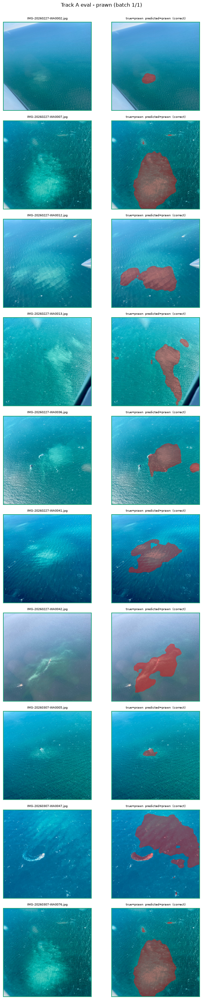

In [20]:
# --- Prawn eval images ---
plot_class("prawn")

tuna: 38 / 40 correct


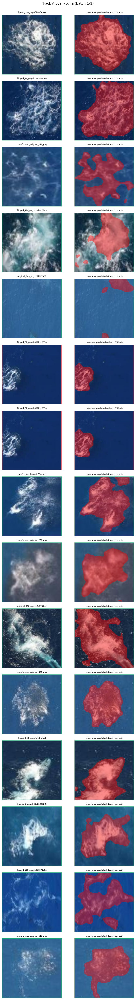

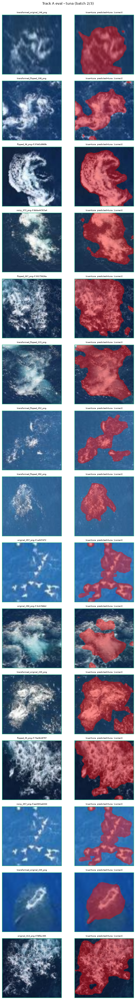

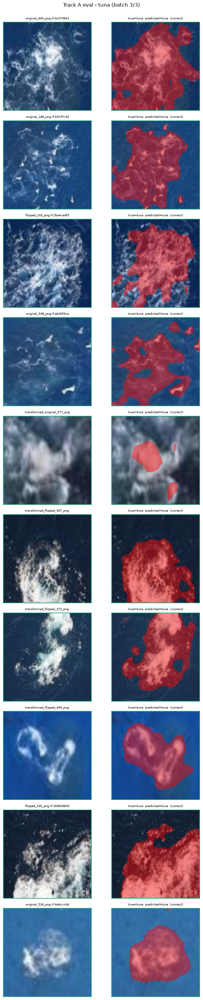

In [21]:
# --- Tuna eval images ---
plot_class("tuna")

other: 14 / 15 correct


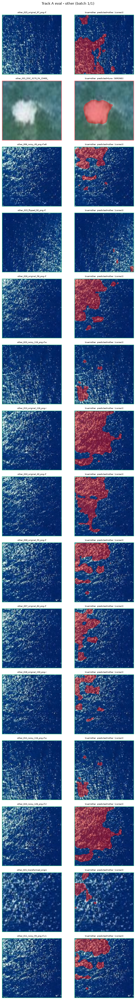

In [22]:
# --- Other eval images ---
plot_class("other")

3 wrong prediction(s) out of 65


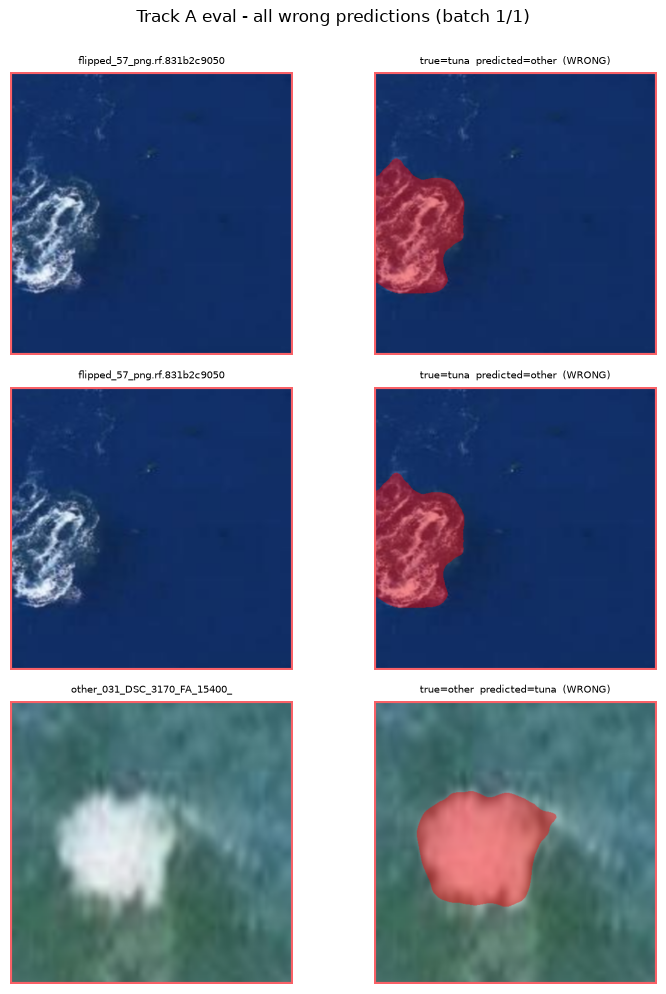

In [23]:
# --- Just the wrong ones, for a quick look without scrolling through all 65 ---

wrong = [r for r in eval_display if not r["correct"]]
print(f"{len(wrong)} wrong prediction(s) out of {len(eval_display)}")
if wrong:
    plot_batch(wrong, 1, 1, "Track A eval - all wrong predictions")